### Importar as bibliotecas

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')

### Carregar os dados

In [16]:
df = pd.read_csv('../dataset/limpo.csv')

### Resumo dos números

In [4]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,price_per_sqft
count,4.549000e+03,4549.000000,4549.000000,4549.000000,4.549000e+03,4549.000000,4549.000000,4549.000000,4549.000000,4549.000000,4549.000000,4549.000000,4549.000000,4549.000000
mean,5.576257e+05,3.396131,2.155968,2131.578809,1.483460e+04,1.511651,0.006595,0.234337,3.449549,1821.291932,310.286876,1970.787206,808.036272,268.719237
std,5.638915e+05,0.901988,0.775205,955.234941,3.597114e+04,0.537794,0.080949,0.765085,0.675242,853.292493,462.043404,29.763891,979.313181,358.427570
min,7.800000e+03,1.000000,0.750000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000,10.000000
25%,3.261000e+05,3.000000,1.750000,1460.000000,5.000000e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000,182.850000
50%,4.650000e+05,3.000000,2.250000,1970.000000,7.680000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000,245.410000
75%,6.575000e+05,4.000000,2.500000,2610.000000,1.097000e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,600.000000,1997.000000,1999.000000,315.680000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000,22533.900000


### Distribuição dos preços

O histograma mostra como os preços estão distribuídos.
Muitos valores à direita indicam imóveis mais caros.

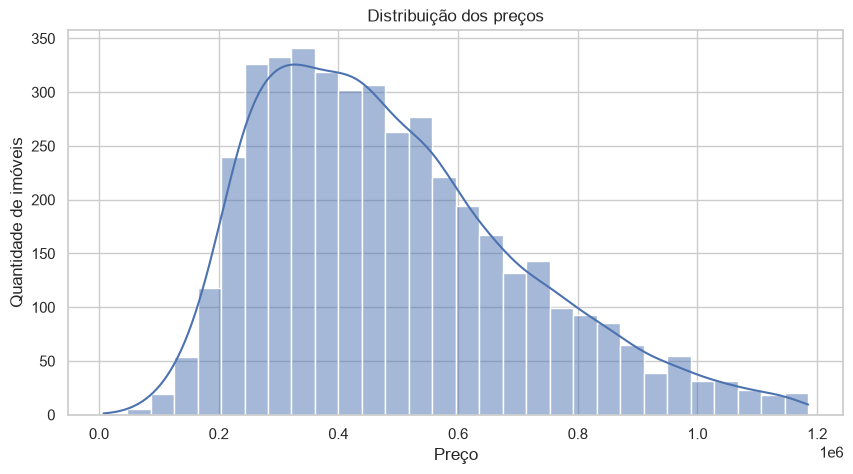

In [17]:
plt.figure(figsize=(10, 5))
limite_preco = df['price'].quantile(0.95)
precos_grafico = df[df['price'] <= limite_preco]
sns.histplot(data=precos_grafico, x='price', bins=30, kde=True)
plt.title('Distribuição dos preços')
plt.xlabel('Preço')
plt.ylabel('Quantidade de imóveis')
plt.show()

### Preço e área habitável

Cada ponto representa um imóvel.
Podemos ver se imóveis maiores custam mais.

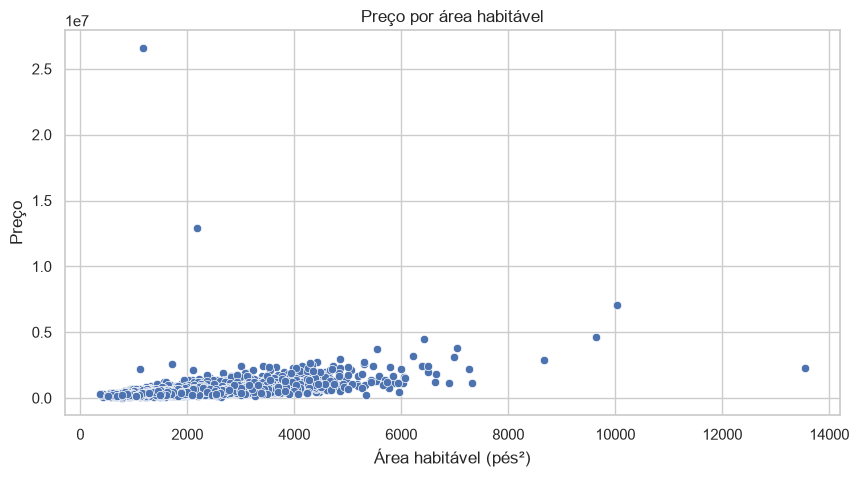

In [18]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='sqft_living', y='price')
plt.title('Preço por área habitável')
plt.xlabel('Área habitável (pés²)')
plt.ylabel('Preço')
plt.show()

### Cidades com mais imóveis

Contagem dos imóveis por cidade.
Mostramos somente as 10 primeiras.

In [15]:
top_cidades = df['city'].value_counts().head(10)

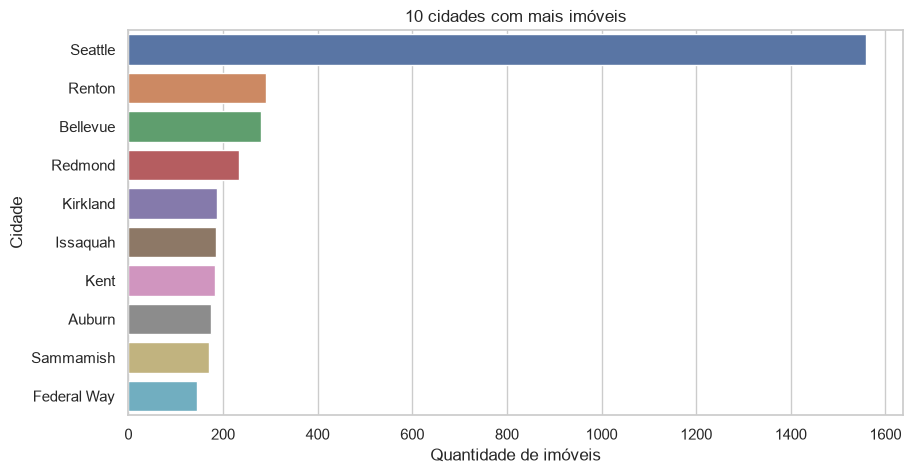

In [8]:
plt.figure(figsize=(10, 5))
sns.barplot(x=top_cidades.values, y=top_cidades.index, hue=top_cidades.index, legend=False)
plt.title('10 cidades com mais imóveis')
plt.xlabel('Quantidade de imóveis')
plt.ylabel('Cidade')
plt.show()

### Preço médio por cidade

Agora agrupamos os imóveis por cidade.
Depois, calculamos a média de preço.

In [14]:
preco_medio_cidade = df.groupby('city')['price'].mean().sort_values(ascending=False).head(10)

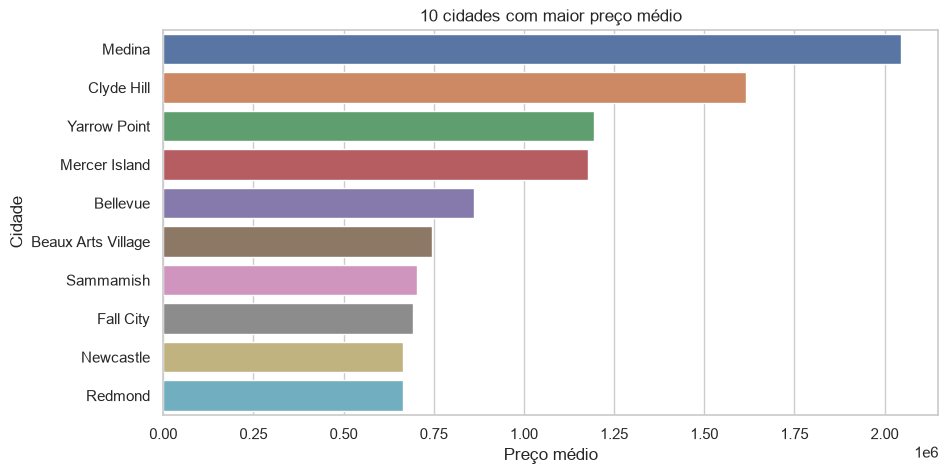

In [10]:
plt.figure(figsize=(10, 5))
sns.barplot(x=preco_medio_cidade.values, y=preco_medio_cidade.index, hue=preco_medio_cidade.index, legend=False)
plt.title('10 cidades com maior preço médio')
plt.xlabel('Preço médio')
plt.ylabel('Cidade')
plt.show()

### Correlação entre variáveis

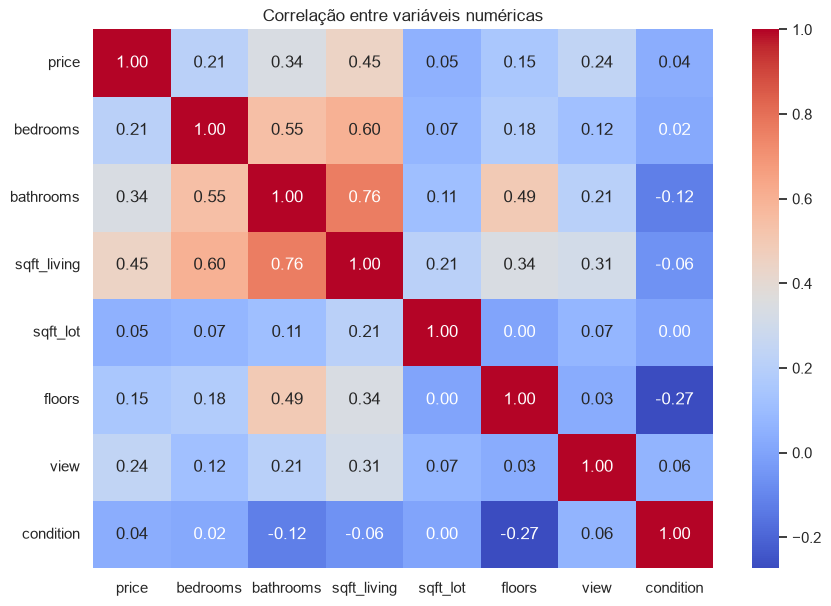

In [22]:
correlacao = df[['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'view', 'condition']].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(correlacao, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlação entre variáveis numéricas')
plt.show()

### Conclusão

A análise mostrou a distribuição dos preços.
Também mostrou a relação entre preço, área e cidade.
Os gráficos ajudam a escolher variáveis para análises futuras.